# Проект: распознавание числовых данных на полевых фотографиях

## Описание проекта
Цель проекта — разработать локальное приложение на основе методов компьютерного зрения и распознавания текста для автоматического извлечения числовых данных с фотографий табличек и последующей систематизации файлов.

Проект ориентирован на автоматизацию ручного переименования и упорядочивания фотографий в полевом фотоархиве. Это должно сократить время первичной обработки материалов и уменьшить количество ошибок, возникающих при ручной работе.

## Предметная область
На фотографиях присутствуют таблички стандартного вида с нанесёнными печатными номерами. Номер может:
- содержать от 1 до 4 цифр;
- иметь одну латинскую букву в конце;
- использовать только буквы: `a`, `b`, `c`, `d`, `e`.

Также на табличке может присутствовать указатель на север, который не должен участвовать в распознавании.

## Основные задачи
В рамках проекта необходимо:
1. Исследовать структуру и качество входных изображений.
2. Разработать подход к выделению области таблички на изображении.
3. Реализовать распознавание числовых данных и конечной буквы.
4. Подготовить логику переименования файлов на основе распознанных значений.
5. Сформировать отчёт о результатах обработки.

## Источник данных
Входными данными являются фотографии, полученные с фотокамеры и сохранённые в папке `data/images/`.

## Ограничения проекта
- приложение должно работать полностью локально;
- не допускается зависимость от облачных сервисов;
- желательно использовать открытые инструменты и библиотеки;
- решение должно быть пригодно для полевых условий.

## Цель текущего ноутбука
Цель данного ноутбука — провести первичный анализ данных и проверить базовую работоспособность пайплайна:
- загрузка изображений;
- просмотр примеров;
- анализ размеров и форматов;
- подготовка к этапу предобработки и распознавания.

In [1]:
from pathlib import Path
import os
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_DIR = Path("../data")
IMAGES_DIR = DATA_DIR / "images"

print("DATA_DIR:", DATA_DIR.resolve())
print("IMAGES_DIR:", IMAGES_DIR.resolve())
print("Папка существует:", IMAGES_DIR.exists())

DATA_DIR: D:\Пет проекты\Sign detect\data
IMAGES_DIR: D:\Пет проекты\Sign detect\data\images
Папка существует: True


In [3]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".raw"}

image_paths = [
    path for path in IMAGES_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in image_extensions
]

print(f"Найдено файлов: {len(image_paths)}")
image_paths[:10]

Найдено файлов: 1200


[WindowsPath('../data/images/MDZ086.JPG'),
 WindowsPath('../data/images/MDZ086_1.JPG'),
 WindowsPath('../data/images/MDZ086_2.JPG'),
 WindowsPath('../data/images/MDZ087 _1.JPG'),
 WindowsPath('../data/images/MDZ087 _10.JPG'),
 WindowsPath('../data/images/MDZ087 _11.JPG'),
 WindowsPath('../data/images/MDZ087 _12.JPG'),
 WindowsPath('../data/images/MDZ087 _2.JPG'),
 WindowsPath('../data/images/MDZ087 _3.JPG'),
 WindowsPath('../data/images/MDZ087 _4.JPG')]

### Базовая информация по изображениям

In [4]:
suffixes = {}

for path in image_paths:
    suffix = path.suffix.lower()
    suffixes[suffix] = suffixes.get(suffix, 0) + 1

print("Количество файлов по форматам:")
for ext, count in sorted(suffixes.items()):
    print(f"{ext}: {count}")

Количество файлов по форматам:
.jpeg: 11
.jpg: 1189


In [5]:
sample_for_sizes = random.sample(image_paths, min(30, len(image_paths)))

sizes = []

for path in sample_for_sizes:
    image = cv2.imread(str(path))
    if image is not None:
        h, w = image.shape[:2]
        sizes.append((path.name, w, h))

print(f"Успешно считано изображений: {len(sizes)}")
print("Пример размеров:")
for item in sizes[:10]:
    print(item)

Успешно считано изображений: 30
Пример размеров:
('MDZ106_1.JPG', 3000, 4000)
('MDZ136_2.JPG', 3000, 4000)
('TUL843_1.JPG', 3456, 4608)
('TUL868_2.JPG', 3456, 5184)
('MDZ087 _10.JPG', 3000, 4000)
('MDZ104_3.JPG', 3000, 4000)
('TUL078_1.JPG', 4000, 6000)
('TUL850_4.JPG', 4608, 3456)
('TUL896_11.JPG', 4000, 6000)
('MDZ125_6.JPG', 3000, 4000)


In [6]:
sample_paths = random.sample(image_paths, min(5, len(image_paths)))
sample_paths

[WindowsPath('../data/images/TUL049.JPG'),
 WindowsPath('../data/images/SDB272.JPG'),
 WindowsPath('../data/images/TUL056.JPG'),
 WindowsPath('../data/images/TUL831_2.JPG'),
 WindowsPath('../data/images/TUL097_1.JPG')]

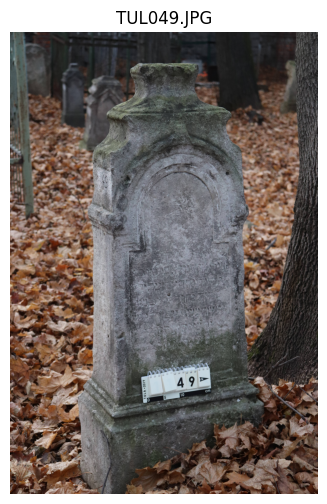

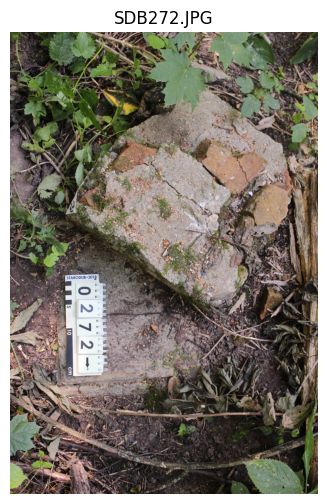

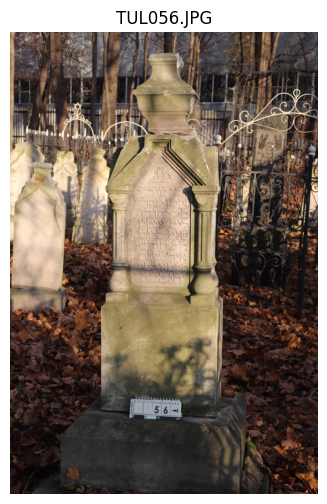

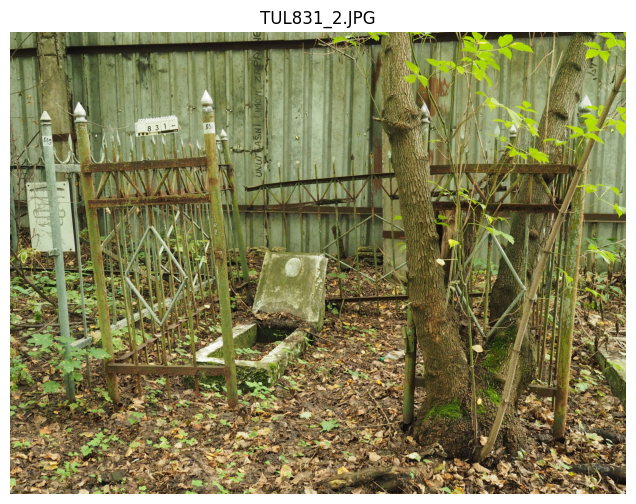

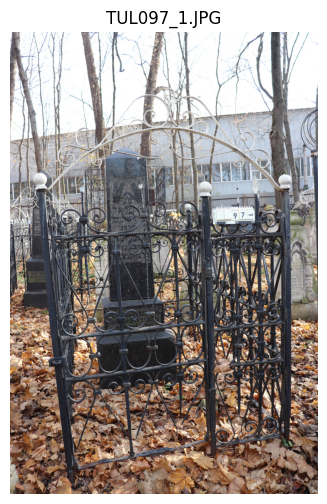

In [7]:
def show_image(path, figsize=(8, 6), title=None):
    image_bgr = cv2.imread(str(path))
    
    if image_bgr is None:
        print(f"Не удалось загрузить: {path}")
        return
    
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=figsize)
    plt.imshow(image_rgb)
    plt.title(title if title else path.name)
    plt.axis("off")
    plt.show()

for path in sample_paths:
    show_image(path, figsize=(8, 6))

### Первичные наблюдения

- таблички на изображении находятся в разных местах;
- размеры разные в зависимости от расстояния, на котором было сделано фото;
- на изображениях таблички находятся не всегда горизонтально, есть небольшой наклон. Также, на одном изображении видно, что табличка находится вертикально;
- номера читаемые;
- На некоторых фото таблички освещены солнцем или находятся в тени. Фон может помешать, если табличка будет расположена рядом с плитой, на которой будет написана дата смерти или другая информация;